In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import RandomOverSampler
import warnings
import pickle
warnings.filterwarnings('ignore')

# load dataset

In [5]:
df = pd.read_csv("C:\\Users\\suhan\\Downloads\\Loan Eligibility Prediction.csv")

# display dataset

In [36]:
df.head()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,0,0,0,0,0,2378,0.0,9,360,1,2,0
1,15,1,1,2,0,0,1299,1086.0,17,120,1,2,1
2,95,1,0,0,1,0,3620,0.0,25,120,1,1,1
3,134,1,1,0,0,1,3459,0.0,25,120,1,1,1
4,556,1,1,1,0,0,5468,1032.0,26,360,1,1,1


In [38]:
df.tail()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,480,1,1,2,0,0,2947,1603.0,10,360,1,2,0
610,525,1,0,0,0,0,4680,2087.0,15,360,1,1,0
611,551,1,1,2,0,1,6633,0.0,25,360,0,0,0
612,552,1,1,1,1,0,2492,2375.0,30,360,1,0,1
613,606,1,1,0,1,0,2400,3800.0,25,180,1,2,0


# dataset shape

In [40]:
df.shape

(614, 13)

# dataset columns

df.columns

# dataset datatypes

In [44]:
df.dtypes

Customer_ID             int64
Gender                  int32
Married                 int32
Dependents              int32
Education               int32
Self_Employed           int32
Applicant_Income        int64
Coapplicant_Income    float64
Loan_Amount             int64
Loan_Amount_Term        int64
Credit_History          int64
Property_Area           int32
Loan_Status             int32
dtype: object

# dataset info

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         614 non-null    int64  
 1   Gender              614 non-null    int32  
 2   Married             614 non-null    int32  
 3   Dependents          614 non-null    int32  
 4   Education           614 non-null    int32  
 5   Self_Employed       614 non-null    int32  
 6   Applicant_Income    614 non-null    int64  
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         614 non-null    int64  
 9   Loan_Amount_Term    614 non-null    int64  
 10  Credit_History      614 non-null    int64  
 11  Property_Area       614 non-null    int32  
 12  Loan_Status         614 non-null    int32  
dtypes: float64(1), int32(7), int64(5)
memory usage: 45.7 KB


# null values in dataset

In [48]:
df.isnull().sum()

Customer_ID           0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
Applicant_Income      0
Coapplicant_Income    0
Loan_Amount           0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

## Exploratory data analysis

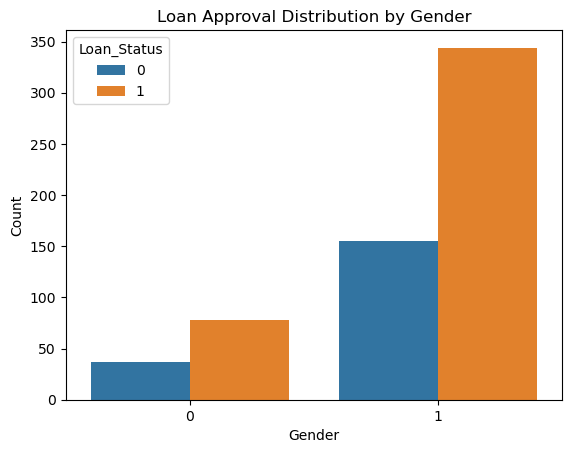

In [50]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

sns.countplot(data=df, x="Gender", hue="Loan_Status")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Loan Approval Distribution by Gender")
plt.show()

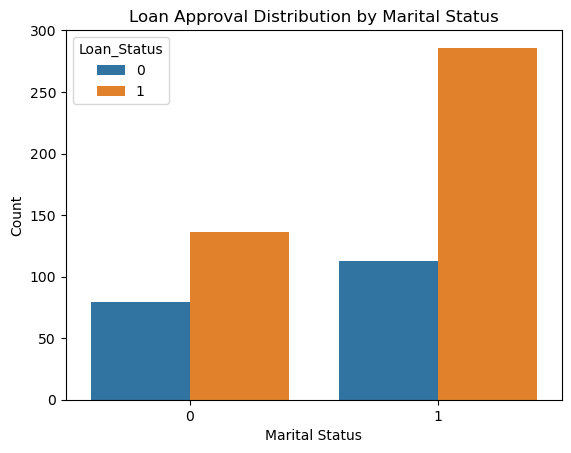

In [52]:
sns.countplot(data=df, x="Married", hue="Loan_Status")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.title("Loan Approval Distribution by Marital Status")
plt.show()

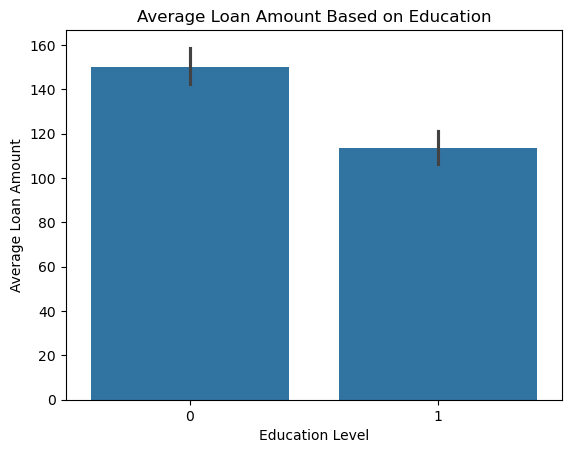

In [54]:
sns.barplot(data=df, x="Education", y="Loan_Amount")
plt.xlabel("Education Level")
plt.ylabel("Average Loan Amount")
plt.title("Average Loan Amount Based on Education")
plt.show()

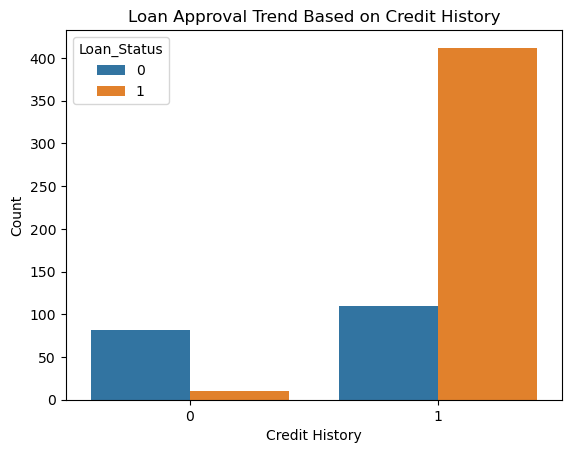

In [58]:
sns.countplot(data=df, x="Credit_History", hue="Loan_Status")
plt.xlabel("Credit History")
plt.ylabel("Count")
plt.title("Loan Approval Trend Based on Credit History")
plt.show()

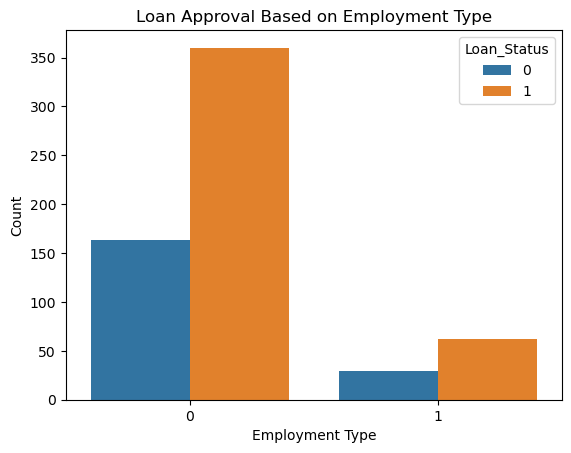

In [56]:
sns.countplot(data=df, x="Self_Employed", hue="Loan_Status")
plt.xlabel("Employment Type")
plt.ylabel("Count")
plt.title("Loan Approval Based on Employment Type")
plt.show()

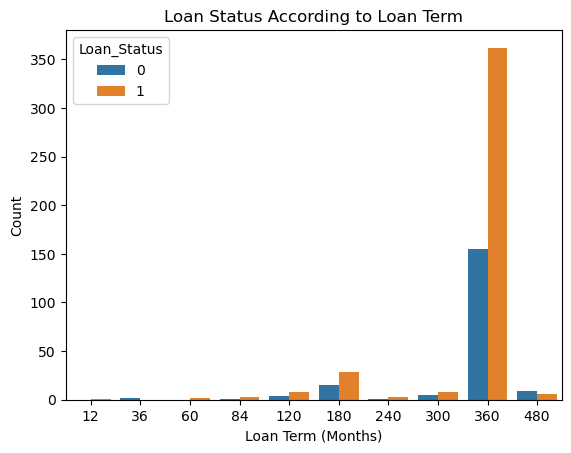

In [60]:
sns.countplot(data=df, x="Loan_Amount_Term", hue="Loan_Status")
plt.xlabel("Loan Term (Months)")
plt.ylabel("Count")
plt.title("Loan Status According to Loan Term")
plt.show()

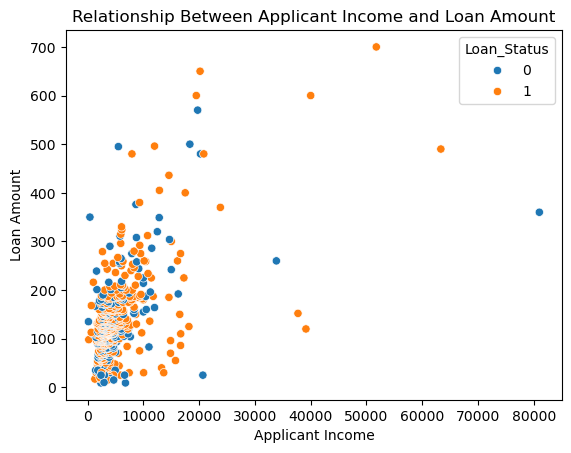

In [62]:
sns.scatterplot(data=df, x="Applicant_Income", y="Loan_Amount", hue="Loan_Status")
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.title("Relationship Between Applicant Income and Loan Amount")
plt.show()

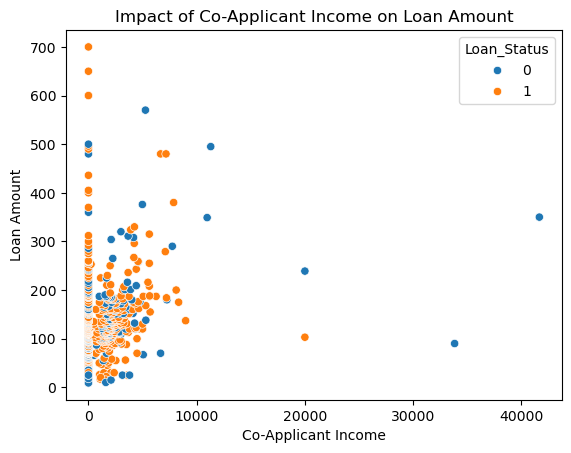

In [64]:
sns.scatterplot(data=df, x="Coapplicant_Income", y="Loan_Amount", hue="Loan_Status")
plt.xlabel("Co-Applicant Income")
plt.ylabel("Loan Amount")
plt.title("Impact of Co-Applicant Income on Loan Amount")
plt.show()

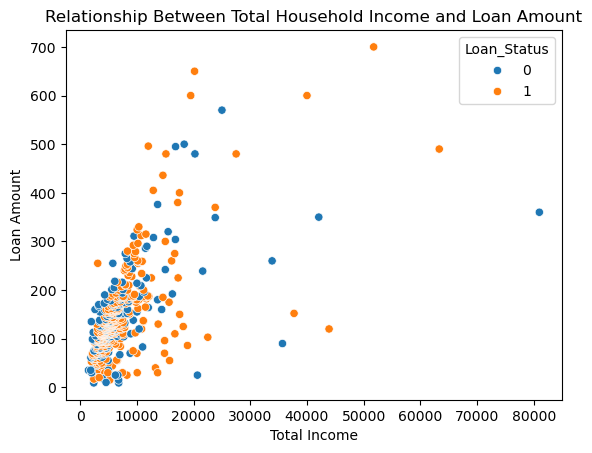

In [66]:
df["Total_Income"] = df["Applicant_Income"] + df["Coapplicant_Income"]
sns.scatterplot(data=df, x="Total_Income", y="Loan_Amount", hue="Loan_Status")
plt.xlabel("Total Income")
plt.ylabel("Loan Amount")
plt.title("Relationship Between Total Household Income and Loan Amount")
plt.show()

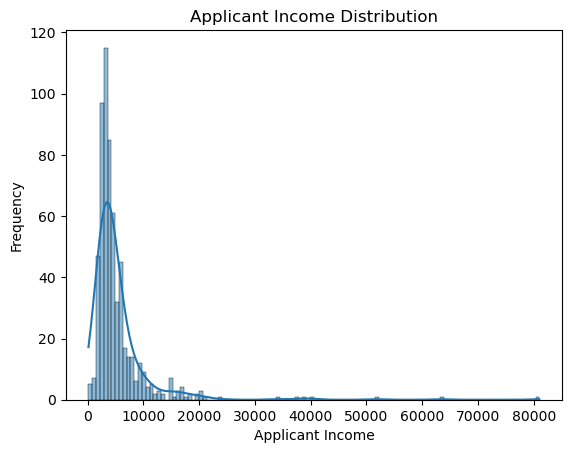

In [68]:
sns.histplot(df["Applicant_Income"], kde=True)
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")
plt.title("Applicant Income Distribution")
plt.show()

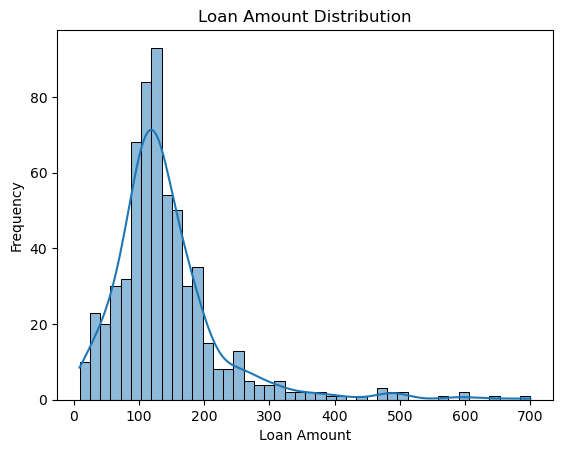

In [70]:
sns.histplot(df["Loan_Amount"], kde=True)
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.title("Loan Amount Distribution")
plt.show()

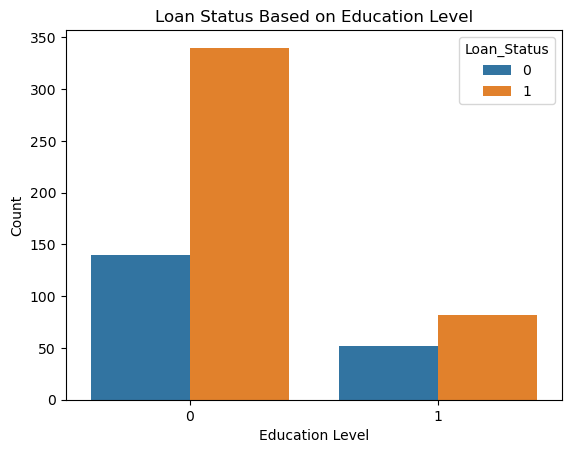

In [72]:
sns.countplot(data=df, x="Education", hue="Loan_Status")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.title("Loan Status Based on Education Level")
plt.show()

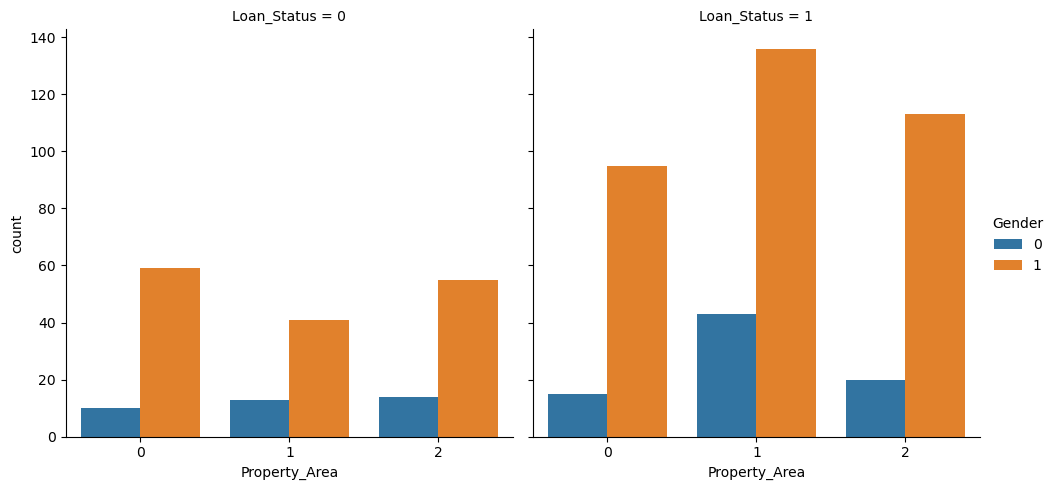

In [74]:
sns.catplot(data=df, x="Property_Area", hue="Gender", col="Loan_Status", kind="count")
plt.show()

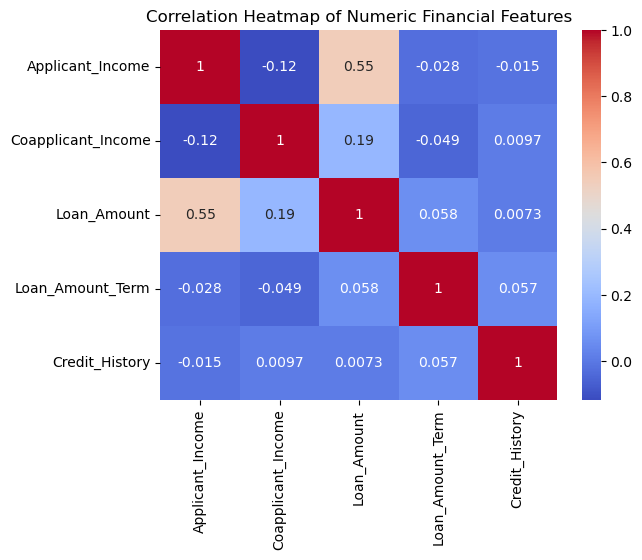

In [76]:
sns.heatmap(df[["Applicant_Income","Coapplicant_Income","Loan_Amount","Loan_Amount_Term","Credit_History"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Financial Features")
plt.show()

# encoding catagorical variables

In [7]:
le = LabelEncoder()
for col in ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']:
    df[col] = le.fit_transform(df[col])



#  Handle '3+' Dependents

In [9]:
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

# Features and Target

In [11]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Handle Class Imbalance

In [15]:
ros = RandomOverSampler(random_state=0)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)


# Feature Scaling

In [17]:
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# define models

In [27]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM (RBF Kernel)": SVC(kernel='rbf', probability=True),
   
}

# train and evaluate

In [93]:
results = {}
for name, model in models.items():
    model.fit(X_train_res_scaled, y_train_res)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix for {name}:\n{cm}")
    print(classification_report(y_test, y_pred))
    print("-"*50)

Logistic Regression Accuracy: 0.8049
Confusion Matrix for Logistic Regression:
[[22 18]
 [ 6 77]]
              precision    recall  f1-score   support

           0       0.79      0.55      0.65        40
           1       0.81      0.93      0.87        83

    accuracy                           0.80       123
   macro avg       0.80      0.74      0.76       123
weighted avg       0.80      0.80      0.79       123

--------------------------------------------------
SVM (RBF Kernel) Accuracy: 0.7886
Confusion Matrix for SVM (RBF Kernel):
[[26 14]
 [12 71]]
              precision    recall  f1-score   support

           0       0.68      0.65      0.67        40
           1       0.84      0.86      0.85        83

    accuracy                           0.79       123
   macro avg       0.76      0.75      0.76       123
weighted avg       0.79      0.79      0.79       123

--------------------------------------------------


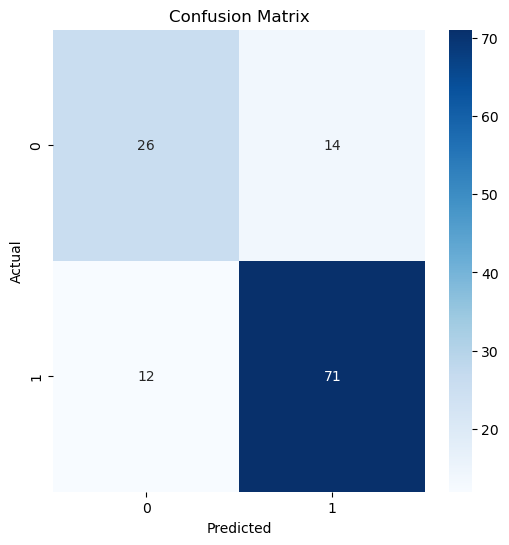

In [98]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# compare models

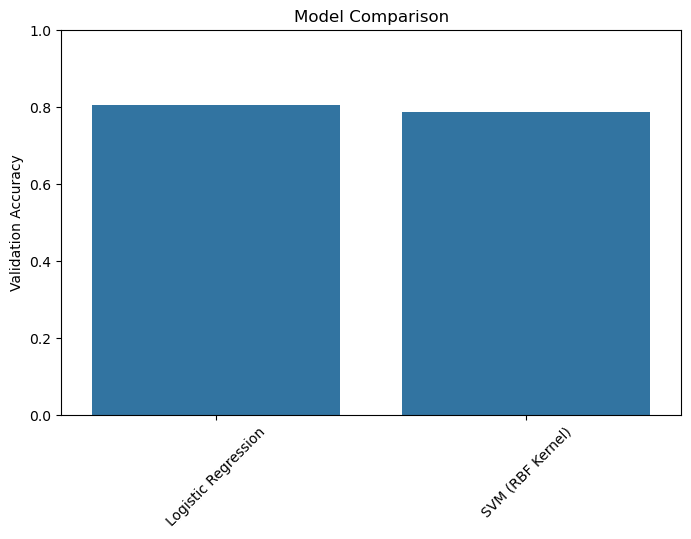

In [31]:
# ----------------- 10. Compare Models -----------------
plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.ylabel("Validation Accuracy")
plt.ylim(0,1)
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.show()


# save best model

In [33]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
pickle.dump(best_model, open('best_loan_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))
print(f"✅ Best model: {best_model_name} saved as 'best_loan_model.pkl'")

✅ Best model: Logistic Regression saved as 'best_loan_model.pkl'
